# Develop quick stuff

For temporary/quick stuff to be developed

In [1]:
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from matplotlib.colors import to_rgb

import torch

import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from berebasl.simulation.credit_data_simulation import CreditData, CreditDataGenerator
from berebasl.simulation import GOOD_BAD_ENCODING
from berebasl.evaluation.batched_metrics import batched_auroc
from berebasl.estimation.classifiers import TorchLogistic

In [2]:
from berebasl.simulation.credit_data_simulation import CreditDataGenerator

grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'
base_sim = 'bias_0_0_corr_0_0'

init_objs_path = os.path.join(grid_path, base_sim, 'initial_simulation_objects_cv_mnar.pt')
dgp_base: CreditDataGenerator = torch.load(init_objs_path, map_location='cpu', weights_only=False)["data_generator"]

In [100]:
list(combinations(range(F), 2))

[(0, 1), (0, 2), (1, 2)]

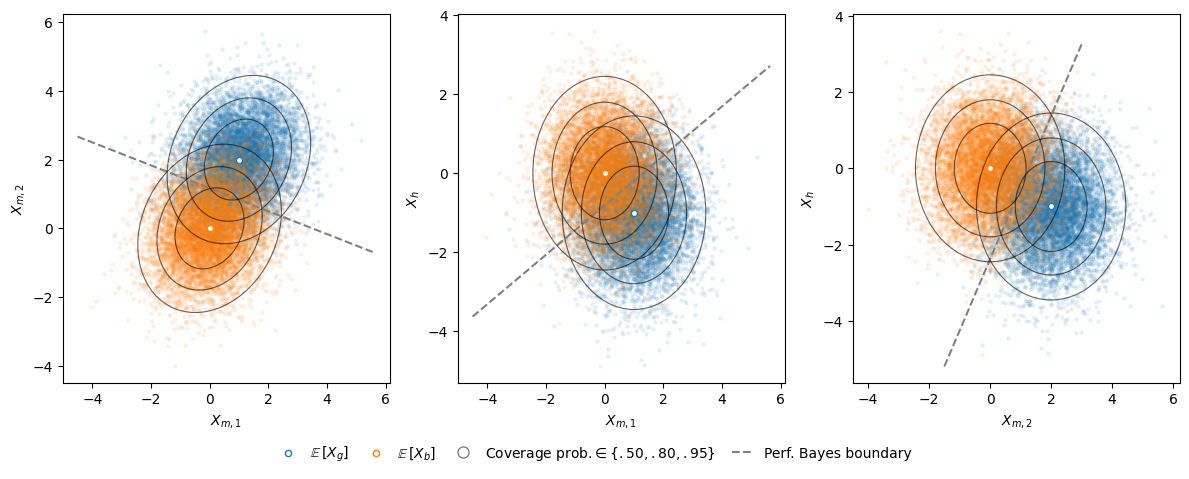

In [111]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(12,4.5))
F = dgp_base.F
aes_dict = {}
lbl_maker = lambda f: f"$X_{{m, {f+1}}}$" if f < F-1 else "$X_{h}$"
for (f1, f2), a_idx in zip(combinations(range(F), 2), range(1, 4)):
    aes_dict[f"{f1:02}{f2:02}"] = fig.add_subplot(1,3, a_idx)
    aes_dict[f"{f1:02}{f2:02}"].set_xlabel(lbl_maker(f1))
    aes_dict[f"{f1:02}{f2:02}"].set_ylabel(lbl_maker(f2))



_, handles_2d, legends_2d = dgp_base.pairwise_plot_dgp(
    sample_size=18_000, axes=[aes_dict]
)

inv_cov = torch.cholesky_inverse(dgp_base.bad_mixture.cov_chol_decomp)
mu_b = dgp_base.bad_mixture.mean
mu_g = dgp_base.good_mixture.mean
pi = dgp_base.prob_bad_given_no_shock

# --- Precompute everything once ---
w = inv_cov @ (mu_b - mu_g)

w0 = -0.5 * (mu_b + mu_g) @ (inv_cov @ (mu_b - mu_g)) + log(pi / (1 - pi))

if dgp_base.simulate_idiosyncratic_shocks:
    # --- Compute noisy shift gamma ---
    pi_s = dgp_base.prob_idiosyncratic_shock
    pi_eps = dgp_base.prob_bad_given_shock
    c = 0.5 + (pi_eps / (1 - pi_eps)) * (0.5 - pi_s)
    gamma = torch.log(c / (1 - c))
else:
    gamma = 0

b = w0 - gamma   # final intercept

# --- Add decision boundary to each 2D subplot ---
# --- Add decision boundary to each 2D subplot ---
for (f1, f2), a_idx in zip(combinations(range(F), 2), range(1, 4)):
    ax = aes_dict[f"{f1:02}{f2:02}"]

    # pick the remaining coordinate index
    f_all = {0,1,2}
    f3 = list(f_all - {f1, f2})[0]

    # grid for x_f1
    x1_vals = torch.linspace(-1.5, 3, 200) if f1==1 and f2==2 else torch.linspace(*ax.get_xlim(), 200)

    # FIXED VALUE FOR THE UNPLOTTED COORDINATE
    x3_fixed = (1 - pi) * mu_g[f3] + pi * mu_b[f3]

    # compute x_f2 from plane equation
    x2_vals = -(b + w[f1] * x1_vals + w[f3] * x3_fixed) / w[f2]

    line, = ax.plot(x1_vals.numpy(), x2_vals.numpy(), color="gray", linestyle="--", linewidth=1.5)


fig.legend(
    handles_2d + [line],
    legends_2d + ["Perf. Bayes boundary"],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.07),
    ncol=len(handles_2d) + 1,
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    columnspacing=1.2
)

fig.tight_layout()

plt.show()

In [95]:
w[f1]

tensor(-1.8750, dtype=torch.float64)

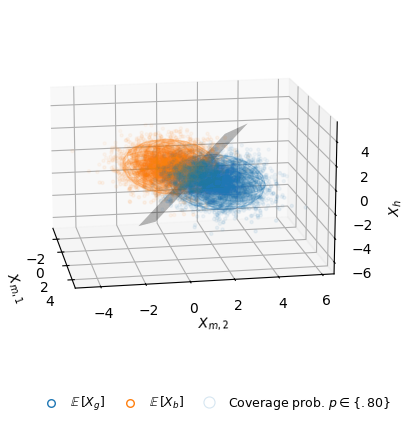

In [ ]:
from math import log

fig = plt.figure(figsize=(12,4.5))

ax = fig.add_subplot(1,1, 1, projection="3d")

dgp_base.plot_credit_dgp_3d(
    sample_size=10_000,
    axes=[ax], elev=15, azim=-10
)
#pos = ax.get_position()
ax.set_box_aspect((4, 5, 3))



# --- Compute LDA direction ---
w = inv_cov @ (mu_b - mu_g)   # shape (3,)

# --- Compute clean intercept w0 ---
pi = dgp_base.prob_bad_given_no_shock
w0 = -0.5 * (mu_b + mu_g) @ (inv_cov @ (mu_b - mu_g)) + log(pi / (1 - pi))

if dgp_base.simulate_idiosyncratic_shocks:
    # --- Compute noisy shift gamma ---
    pi_s = dgp_base.prob_idiosyncratic_shock
    pi_eps = dgp_base.prob_bad_given_shock
    c = 0.5 + (pi_eps / (1 - pi_eps)) * (0.5 - pi_s)
    gamma = torch.log(c / (1 - c))
else:
    gamma = 0

# --- Final intercept for noisy Bayes plane ---
b = w0 - gamma

# --- Create grid for plane ---
xx, yy = torch.meshgrid(
    torch.linspace(-2, 3, 30),
    torch.linspace(-1.2, 3, 30),
    indexing="xy"
)

# Solve for z: w1*x + w2*y + w3*z + b = 0
zz = (-b - w[0]*xx - w[1]*yy) / w[2]

# Convert to numpy for matplotlib
xx_np = xx.numpy()
yy_np = yy.numpy()
zz_np = zz.numpy()

# --- Plot the plane ---
ax.plot_surface(xx_np, yy_np, zz_np, alpha=0.3, color="black")


ax.set_xlabel("$X_{m, 1}$")
ax.set_ylabel("$X_{m, 2}$")
ax.set_zlabel("$X_{h}$")

pos = ax.get_position()
ax.set_position([pos.x0 - 0.1, pos.y0 - 0.05, pos.width + 0.12, pos.height])

#fig.tight_layout()

plt.show()

In [92]:
xx.shape

torch.Size([30, 30])

In [48]:
torch.linalg.inv(dgp_base.bad_mixture.cov), torch.cholesky_inverse(dgp_base.bad_mixture.cov_chol_decomp)

(tensor([[ 1.0417, -0.2083,  0.0000],
         [-0.2083,  1.0417,  0.0000],
         [ 0.0000,  0.0000,  1.0000]], dtype=torch.float64),
 tensor([[ 1.0417, -0.2083, -0.0000],
         [-0.2083,  1.0417, -0.0000],
         [-0.0000, -0.0000,  1.0000]], dtype=torch.float64))